In [24]:
import numpy as np
from matplotlib import pyplot as plt
from analysis import *

np.set_printoptions(precision=3, suppress=True)



In [25]:
class Norm1:
    def __init__(self, acc):
        self.acc = acc
        dim = 6
        G = np.zeros((dim,dim))
        h = np.zeros(dim)

        for a in acc:
            a1,a2,a3 = a
            norm = a@a

            v = np.hstack([a*a, a])
            G += np.outer(v,v)
            h += v

        self.sol = np.linalg.solve(G, h)
        self.s, self.b = self.extract_params(self.sol)

    def extract_params(self, sol):
        s = sol[:3]
        b = sol[3:]
        s = np.sqrt(s)
        b = b / s
        return s, b

    def get_sol(self):
        return sol

    def transform(self, x):
        y = s * x + b
        return s

class Norm1Rotate:
    def __init__(self, acc):
        self.acc = acc
        dim = 9
        G = np.zeros((dim,dim))
        h = np.zeros(dim)

        for a in acc:
            a1,a2,a3 = a
            v = np.array([a1 ** 2, a2 ** 2, a3 ** 2,
                2 * a1 * a2, 2 * a1 * a3, 2 * a2 * a3, a1, a2, a3])

            G += np.outer(v,v)
            h += v

        self.sol = np.linalg.solve(G, h)
        # self.s, self.b = self.extract_params(self.sol)

    def extract_params(self, sol):
        s = sol[:3]
        b = sol[3:]
        s = np.sqrt(s)
        b = b / s
        return s, b

    def get_sol(self):
        return sol

    def transform(self, x):
        y = s * x + b
        return s

In [26]:
class AlignGyro:
    def __init__(self, gyro, acc, dt):

        G = np.zeros((7,7))
        h = np.zeros(7)

        for i in range(1,len(acc)):
            a1,a2,a3 = a = acc[i-1] 
            b1,b2,b3 = b = acc[i]
            x1,x2,x3 = x = gyro[i]

            weight = abs(1 - a @ b)
            weight = 1

            cross = np.cross(a,b) * dt
            dot = a @ b
            v = np.hstack([[dot], 0.5 * cross * x, cross])
            G += np.outer(v,v) * weight
            h += v * weight

        sol = np.linalg.solve(G, h)
        sol = sol / sol[0]
        self.sol = sol

### Simulated test

In [27]:
from scipy.spatial.transform import Rotation as R
from scipy.linalg import expm

acc,gyro,ts = [],[],[]
dt = 18 * 1e-4
noise = 0.01

def get_noise():
    return np.random.randn(3) * noise

rot = R.random().as_matrix()
a = np.random.randn(3)
a /= np.linalg.norm(a)

g = np.random.randn(3)

for i in range(1000):
    g = np.random.randn(3) # random walk i guess
    g1,g2,g3 = g
    A = np.array([
        [0, g3, -g2],
        [-g3,0,g1],
        [g2,-g1,0]])
    R = expm(-A * dt)
    a = R @ a
    bg = g / [5,2,3] - [.4,-.2,.3]
    acc.append(a + get_noise() * 5)
    gyro.append(bg + get_noise())
    ts.append(dt)

acc = np.array(acc)
gyro = np.array(gyro)
ts = np.array(ts)


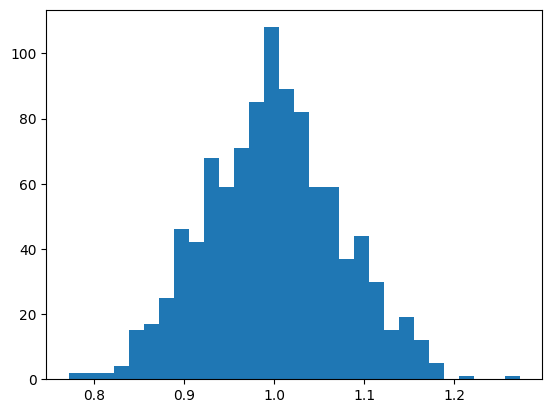

In [28]:
dots = np.array([acc[i-1] @ acc[i] for i in range(1, len(acc))])
plt.hist(dots, 30); plt.show()

In [29]:
sol = AlignGyro(gyro, acc, dt).sol
sol


array([   1.   , -110.544,  135.346,  206.074,   -8.959, -502.395,
       -133.992])

### IMU data

In [40]:
data = np.loadtxt("data/gyroacc.txt")
mag = data[:, 0:3]
acc = data[:, 3:6]
gyro = data[:, 6:9]
ts = data[:, 9] * 1e-4

gyro -= np.mean(gyro[:10], axis=0)

solver = Norm1(mag)
scale, bias = solver.s, solver.b
mag *= scale
mag += bias

# acc /= 9.8
# acc /= np.linalg.norm(acc, keepdims=True, axis=1)

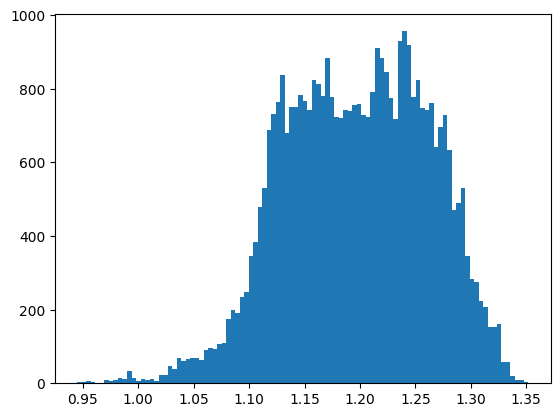

In [39]:
plt.hist(np.linalg.norm(mag, axis=1), bins=100); plt.show()

In [20]:
i = 200
print(gyro[i-1])
print(gyro[i])
print("")
print(acc[i-1])
print(acc[i])

[ 0.002 -0.005 -0.003]
[ 0.008 -0.003 -0.007]

[-0.083 -0.035  0.993]
[-0.094 -0.038  0.999]


In [46]:
data = np.loadtxt("data/gyroacc.txt")
mag = data[:, 0:3]
acc = data[:, 3:6]
gyro = data[:, 6:9]
dts = data[:, 9] * 1e-4

solver = Norm1(acc)
scale, bias = solver.s, solver.b
acc -= bias
acc *= scale
Norm1(acc).sol

array([1.   , 1.   , 1.004, 0.017, 0.026, 0.101])

In [191]:
bias

array([-0.508, -0.656, -0.612])

In [47]:
sol = AlignGyro(gyro, mag, dt).sol
sol


array([     1.   ,  -5495.072, -15304.373,   2454.397,   -225.693,
          193.065,   -204.757])

In [161]:
np.linalg.norm(gyro, axis=1)

array([0.004, 0.001, 0.006, ..., 0.279, 0.22 , 0.175], shape=(4844,))

In [ ]:
assert False

## Norm 1

In [ ]:
data = np.loadtxt("data/gyroacc.txt")
mag = data[:, 0:3]
acc = data[:, 3:6]
gyro = data[:, 6:9]
dts = data[:, 9]

acc /= 9.8
# acc /= np.linalg.norm(acc, keepdims=True, axis=1)

array([ 1.,  1.,  1.,  0.,  0., -0.])

In [42]:
s = sol[:3]
b = sol[3:]
s = np.sqrt(s)
b = b / s
print(s, b)

[0.999 1.002 0.99 ] [0.012 0.018 0.015]


In [ ]:
norms = np.linalg.norm(acc, axis=1)
plt.hist(norms, bins=100, alpha=0.5)

newacc = s * acc + b
norms = np.linalg.norm(newacc, axis=1)
plt.hist(norms, bins=100, alpha=0.5)
plt.show()

## Derive linear system

In [ ]:
from sympy import symbols
a1, a2, a3 = symbols('a1 a2 a3')
b1, b2, b3 = symbols('b1 b2 b3')
x1, x2, x3 = symbols('x1 x2 x3')
c1, c2, c3 = symbols('c1 c2 c3')
s1, s2, s3 = symbols('s1 s2 s3')
t = symbols('t')

a = np.array([a1,a2,a3])
b = np.array([b1,b2,b3])
x = np.array([x1,x2,x3])
s = np.array([s1,s2,s3])
c = np.array([c1,c2,c3])


In [ ]:
p1,p2,p3 = p = (s * x + c) * t

R = np.array([
    [1, p3, -p2],
    [-p3,1,p1],
    [p2,-p1,1]
])
y = b @ R @ a
y = y.expand()
y

In [ ]:
y0 = y.xreplace({s1:0, s2:0, s3:0, c1:0, c2:0, c3:0})
z = y.xreplace({s1:0, s2:0, s3:0, c1:0, c2:1, c3:0}) - y0
z.expand()

## Save off data from Serial

In [4]:
import serial
import serial.tools.list_ports as port_list
ports = list(port_list.comports())
for p in ports:
    print (p)



COM5 - USB-SERIAL CH340 (COM5)


In [5]:

ser = serial.Serial(
    'COM5', 115200, 
    timeout=None, parity=serial.PARITY_NONE, 
    stopbits=serial.STOPBITS_ONE, bytesize=serial.EIGHTBITS)


In [6]:
data = []

while True:
    try:
        line = ser.read_until(b"\r\n")
        line = line.strip() # remove whitespace
        line = line.split(b",")
        line = np.array([float(i) for i in line])
        data.append(line)
    except ValueError:
        pass


SerialException: GetOverlappedResult failed (PermissionError(13, 'Access is denied.', None, 5))

In [14]:
[i for i,d in enumerate(data) if len(d) != 10]

[17264]

In [16]:
data = [d for i,d in enumerate(data) if len(d) == 10]
data = np.array(data[10:-10])
np.savetxt("data/gyroacc.txt", data)

In [15]:
len(data)

39178